In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = False

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

ELBO = 203193940.55072194, change = 1.5204168226739248e-08, time taken = 2.084367513656616: 100%|██████████| 500/500 [17:22<00:00,  2.09s/it] 

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2841471480.153315, 79764019.60554188, 164528762.69790402, 197079181.92756554, 201713109.37423956, 203077540.64842948, 203149165.55286077, 203159189.51431662, 203163520.01662615, 203165944.4835236, 203167808.14549845, 203169233.49533194, 203170446.97864816, 203171370.58731055, 203172204.6580245, 203173012.87655354, 203173780.9488608, 203174403.36665913, 203174959.4666946, 203175498.45024335, 203176028.44980562, 203176552.83642685, 203177007.14312238, 203177388.2602387, 203177737.92795137, 203178076.17225364, 203178406.06358907, 203178739.5255936, 203179062.74600348, 203179357.78797722, 203179606.30619267, 203179824.87927127, 203180032.06215894, 203180223.55843356, 203180400.57521823, 203180574.73717916, 203180750.35611552, 203180929.0236133, 203181116.43149018, 203181329.75342238, 203181606.41456196, 203181913.55479616, 203182040.75138295, 203182128.66167828, 203182228.69596294, 203182333.14

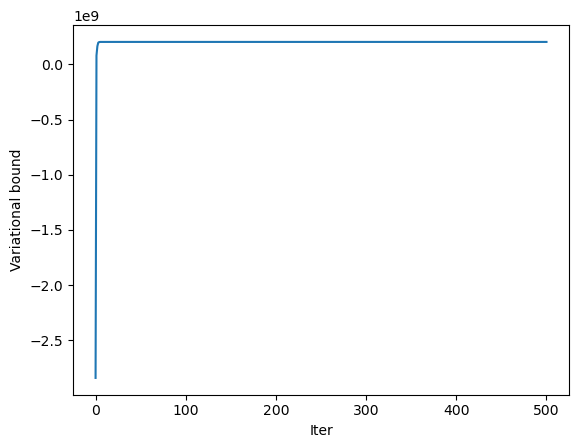

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-10
verbose = True

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

ELBO = 202249387.91983965, change = 2.2277784569929e-08, time taken = 2.082850694656372: 100%|██████████| 500/500 [17:22<00:00,  2.08s/it]    

Number of negative deltas: 3
When do they occur? [441, 442, 497]
what is their magnitude? [-5.383236482932611e-08, -2.52987553883728e-08, -1.551461953292626e-08]
List of elbos: [-2720485516.0876336, 86422691.39564547, 170098779.2860185, 197415950.70252076, 201865101.90379396, 202189933.07812926, 202211287.07484734, 202217779.96333018, 202221100.137046, 202223246.40836388, 202224688.2903709, 202225881.61163086, 202226847.47103244, 202227671.9606956, 202228394.14547816, 202229034.71190146, 202229615.93632463, 202230141.6358404, 202230620.09691015, 202231063.59833875, 202231482.0645611, 202231879.59346092, 202232259.4877979, 202232635.6594364, 202233025.98975247, 202233473.78380933, 202233961.24522135, 202234280.58612576, 202234582.39065406, 202234871.42823917, 202235067.86014742, 202235240.6083005, 202235402.0381497, 202235556.38828778, 202235708.04923424, 202235859.52499387, 202236007.38432038, 202236153.0604412, 202236299.0434946, 202236446.6985895, 202236599.2702637, 202236760.4252869

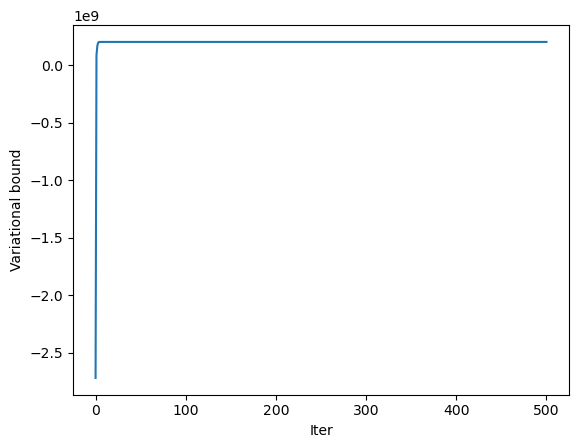

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

ELBO = 202271759.75471026, change = 4.324638813176815e-08, time taken = 2.0840368270874023: 100%|██████████| 500/500 [17:22<00:00,  2.09s/it] 

Number of negative deltas: 1
When do they occur? [178]
what is their magnitude? [-9.64436200521813e-09]
List of elbos: [-2828206475.936899, 85363667.66442382, 175050755.21167374, 199774870.53115073, 202076738.36330262, 202217656.457131, 202233906.33789775, 202239611.9396112, 202242392.45103896, 202244553.6472516, 202246428.02980903, 202247920.38780624, 202249014.2515354, 202249969.05521628, 202250952.0731261, 202251608.10999537, 202252208.0621897, 202252807.70692763, 202253377.24025774, 202253792.82609424, 202254154.2061502, 202254519.25930482, 202254895.49335995, 202255298.04721066, 202255760.58060628, 202256322.7240586, 202256738.5830952, 202256936.74971533, 202257128.86394265, 202257321.4262714, 202257517.19365606, 202257722.95490375, 202257954.87776148, 202258244.15532392, 202258585.75122592, 202258765.22709268, 202258895.34491593, 202259024.9325968, 202259166.5088516, 202259319.32916155, 202259490.78956035, 202259705.224891, 202259996.4467534, 202260171.97454923, 202260243.6131256

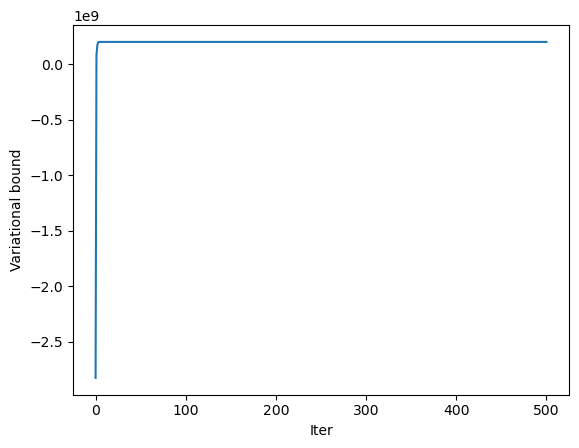

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Change is small enough, early break: 100%|█████████▉| 499/500 [17:24<00:02,  2.09s/it]                                                         

Number of negative deltas: 26
When do they occur? [142, 143, 144, 204, 205, 277, 278, 279, 281, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 498, 499]
what is their magnitude? [-3.9612153477700645e-08, -4.076753657507018e-08, -3.4085984687221706e-09, -3.212986610588996e-08, -2.1626220392078887e-08, -6.41381377330467e-10, -1.6544440050019988e-09, -6.058193517782667e-10, -4.949184293085359e-10, -1.1689483637383376e-09, -1.8112018643099126e-09, -1.6900111565479714e-09, -2.6734225808036146e-09, -4.211149584343784e-09, -3.5619108476077726e-09, -2.7773632137760977e-09, -4.493908698274732e-09, -5.933252709900185e-09, -5.572321097463084e-09, -4.823276792198706e-09, -3.5596265241194916e-09, -2.307478708246283e-09, -2.864798208483997e-09, -1.5370435064928957e-09, -8.766860489619835e-10, -1.6303460160397356e-12]
List of elbos: [-2835848379.932782, 86810705.10269113, 175988713.34681737, 201229115.275311, 203085239.71412063, 203176683.00252262, 203189012.9540696, 20319

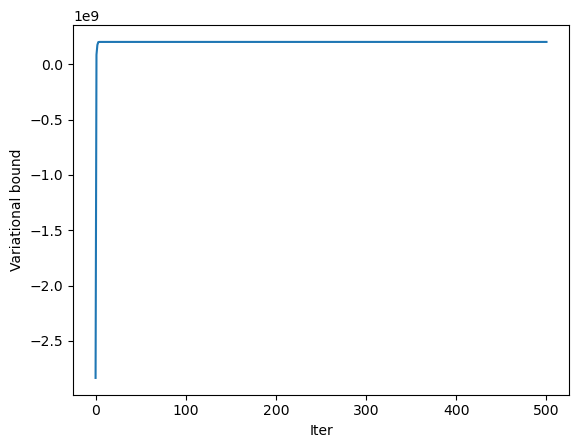

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

ELBO = 203761773.021551, change = 3.567375189647648e-08, time taken = 2.0121703147888184: 100%|██████████| 500/500 [16:47<00:00,  2.01s/it]    

Number of negative deltas: 6
When do they occur? [361, 362, 363, 364, 365, 366]
what is their magnitude? [-1.1829749152117617e-09, -3.393218428408826e-08, -4.5513338797361215e-08, -3.291565482800916e-08, -1.6755700035562544e-08, -5.002749538563344e-09]
List of elbos: [-2861491077.1201997, 81673561.56025007, 164281490.83090732, 199929224.04844445, 203537241.7445631, 203705587.45784026, 203723829.18277562, 203730247.45777333, 203733405.08703855, 203735323.41841957, 203736984.80542544, 203738390.55492774, 203739466.88813058, 203740362.80112112, 203741265.71849272, 203742032.94816858, 203742575.8723949, 203743083.4954927, 203743571.1246315, 203744036.65095577, 203744487.53622395, 203744940.24409124, 203745434.32963964, 203745913.0913902, 203746212.26150787, 203746481.2794963, 203746753.72312096, 203747022.33154812, 203747294.4468761, 203747591.3569266, 203747951.15232506, 203748335.92731056, 203748527.04616073, 203748677.1045176, 203748834.31064165, 203748993.02544346, 203749150.65118006, 

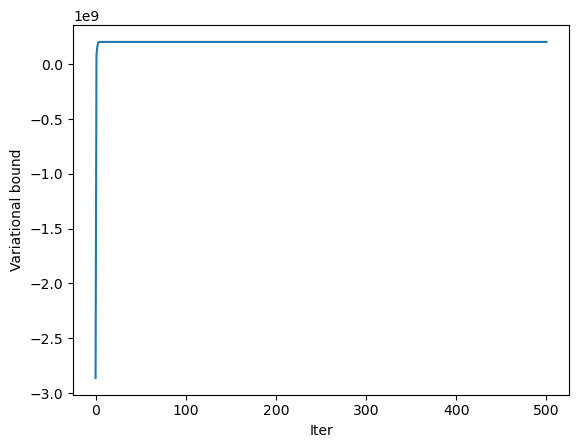

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)